First 5 rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0



Dataset Shape: (150, 5)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB

Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

Statistical Summary:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


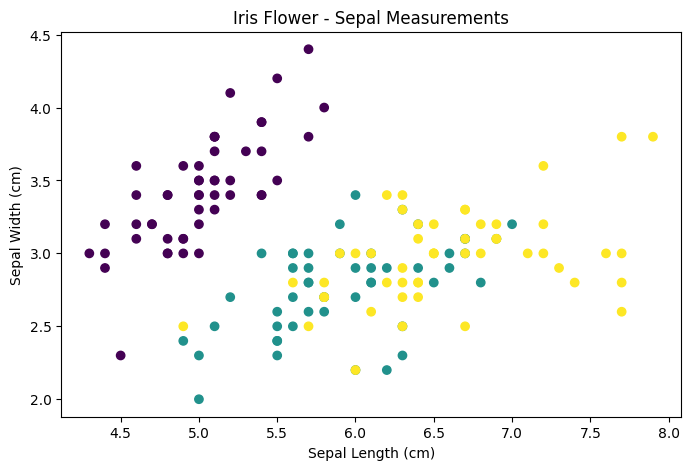

Training samples: 120
Testing samples: 30

Model Accuracy:
93.33%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



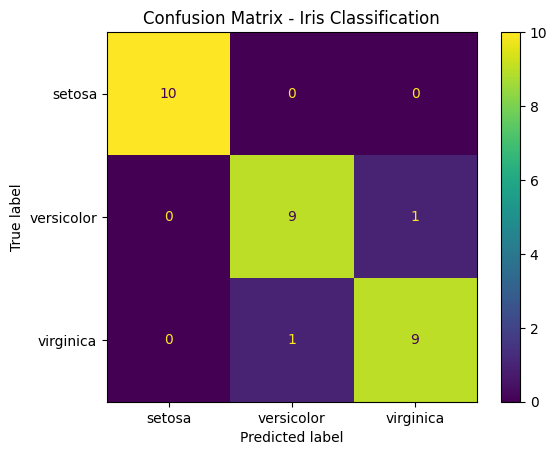


Predicted Flower Species:
setosa


In [2]:
# CodeAlpha Internship - Task 1
# Iris Flower Classification

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Load Iris dataset
iris = load_iris()

# Create DataFrame
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["species"] = iris.target

# Display first 5 rows
print("First 5 rows:")
display(df.head())

# Dataset information
print("\nDataset Shape:", df.shape)
print("\nDataset Information:")
df.info()

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Statistical summary
print("\nStatistical Summary:")
display(df.describe())

# -----------------------------
# Data Visualization
# -----------------------------

plt.figure(figsize=(8, 5))

plt.scatter(
    df["sepal length (cm)"],
    df["sepal width (cm)"],
    c=df["species"]
)

plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")
plt.title("Iris Flower - Sepal Measurements")
plt.show()

# -----------------------------
# Prepare data
# -----------------------------

X = iris.data
y = iris.target

# Split dataset into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

# -----------------------------
# Feature Scaling
# -----------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -----------------------------
# Train Machine Learning Model
# -----------------------------

model = LogisticRegression(max_iter=200)

model.fit(X_train_scaled, y_train)

# -----------------------------
# Make Predictions
# -----------------------------

y_pred = model.predict(X_test_scaled)

# -----------------------------
# Evaluate Model
# -----------------------------

accuracy = accuracy_score(y_test, y_pred)

print("\nModel Accuracy:")
print(f"{accuracy * 100:.2f}%")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names
    )
)

# -----------------------------
# Confusion Matrix
# -----------------------------

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)

disp.plot()
plt.title("Confusion Matrix - Iris Classification")
plt.show()

# -----------------------------
# Test a New Flower
# -----------------------------

new_flower = [[5.1, 3.5, 1.4, 0.2]]

new_flower_scaled = scaler.transform(new_flower)

prediction = model.predict(new_flower_scaled)

print("\nPredicted Flower Species:")
print(iris.target_names[prediction][0])

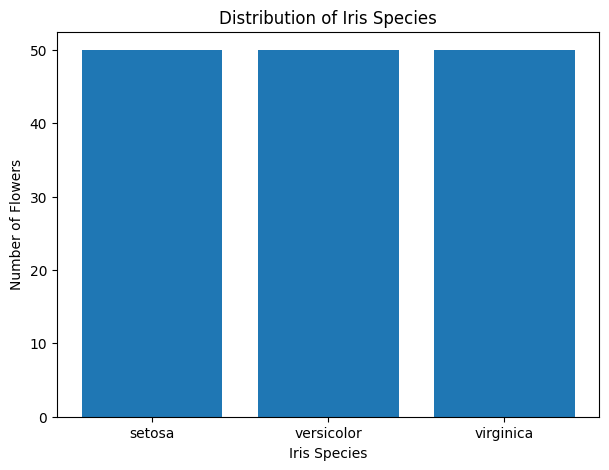

In [3]:
# Count the number of flowers in each species

species_counts = df["species"].value_counts().sort_index()

species_names = iris.target_names

plt.figure(figsize=(7, 5))

plt.bar(species_names, species_counts)

plt.xlabel("Iris Species")
plt.ylabel("Number of Flowers")
plt.title("Distribution of Iris Species")

plt.show()

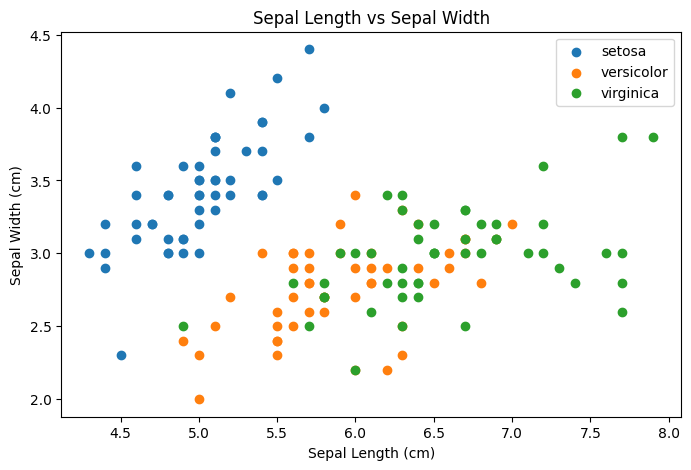

In [4]:
# Sepal Length vs Sepal Width

plt.figure(figsize=(8, 5))

for species in range(3):
    subset = df[df["species"] == species]

    plt.scatter(
        subset["sepal length (cm)"],
        subset["sepal width (cm)"],
        label=iris.target_names[species]
    )

plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")
plt.title("Sepal Length vs Sepal Width")
plt.legend()

plt.show()

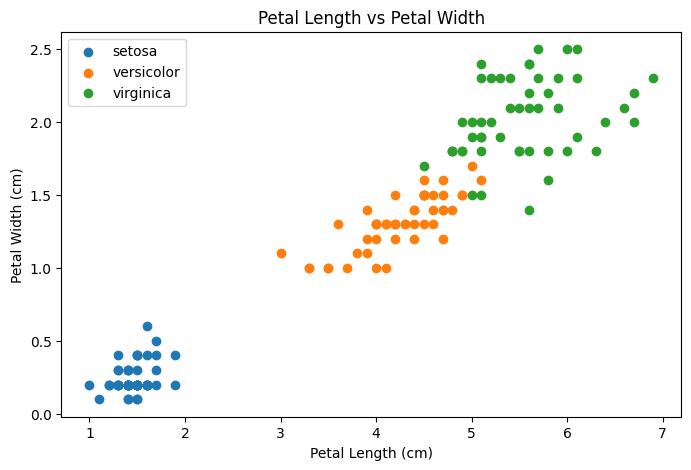

In [5]:
# Petal Length vs Petal Width

plt.figure(figsize=(8, 5))

for species in range(3):
    subset = df[df["species"] == species]

    plt.scatter(
        subset["petal length (cm)"],
        subset["petal width (cm)"],
        label=iris.target_names[species]
    )

plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title("Petal Length vs Petal Width")
plt.legend()

plt.show()


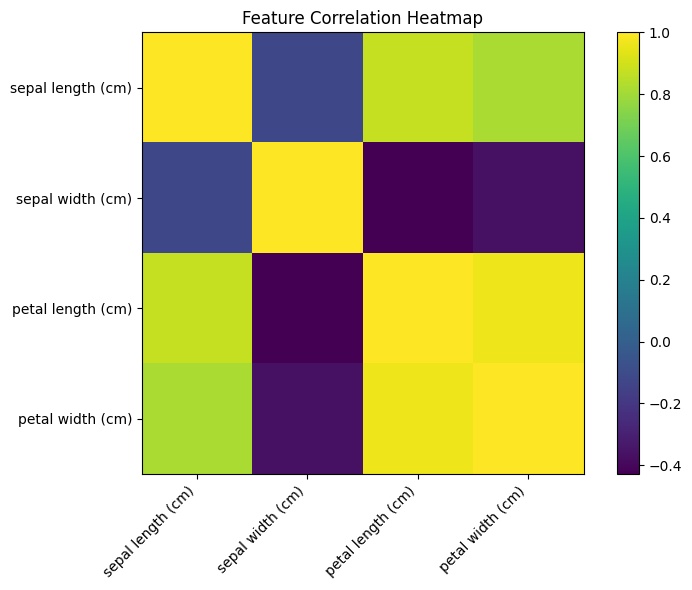

In [7]:
# Correlation between flower measurements

correlation_matrix = df.drop(columns=["species"]).corr()

plt.figure(figsize=(8, 6))

plt.imshow(correlation_matrix, cmap="viridis")

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Feature Correlation Heatmap")

plt.tight_layout()

plt.show()


In [8]:
# Prepare data for machine learning

X = iris.data
y = iris.target

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (150, 4)
Target shape: (150,)


In [9]:
# Split the dataset into training and testing data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 120
Testing samples: 30


In [10]:
# Create and train the Logistic Regression model

model = LogisticRegression(max_iter=200)

model.fit(X_train, y_train)

print("Model training completed successfully!")


Model training completed successfully!


In [11]:
# Make predictions on the test data

y_pred = model.predict(X_test)

print("Predictions completed successfully!")


Predictions completed successfully!


In [12]:
# Calculate model accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:")
print(f"{accuracy * 100:.2f}%")

Model Accuracy:
96.67%


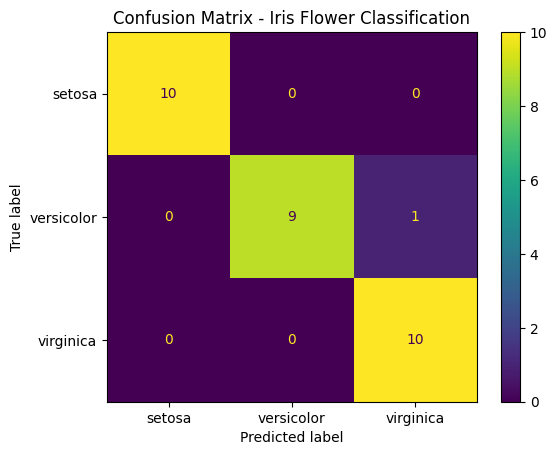

In [13]:
# Create a confusion matrix

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)

disp.plot()

plt.title("Confusion Matrix - Iris Flower Classification")

plt.show()

In [14]:
# Generate classification report

print("Classification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names
    )
)

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



# Conclusion

In this project, a machine learning model was developed to classify Iris flowers
into three species: Setosa, Versicolor, and Virginica.

The dataset contains 150 flower samples with four input features:
sepal length, sepal width, petal length, and petal width.

Exploratory data analysis was performed using different visualizations.
The petal measurements showed clear separation between the three Iris species.

The dataset was divided into 120 training samples and 30 testing samples.
A Logistic Regression model was trained using the training data.

The model achieved an accuracy of 96.67% on the test dataset.

The classification report showed strong precision, recall, and F1-score across
all three species. The confusion matrix showed that 29 out of 30 test samples
were classified correctly.

Overall, the results demonstrate that Logistic Regression can effectively
classify Iris flower species using their physical measurements.